In [1]:
%%writefile .gitignore
# Ignore the raw dataset (Never upload large data to GitHub!)
Data/
PlantVillage/

# Ignore Jupyter notebook checkpoints
.ipynb_checkpoints/

# Ignore saved heavy model files
models/*.keras
models/*.h5

# Ignore Python cache
__pycache__/
*.pyc

Overwriting .gitignore


In [11]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

In [12]:
dataset_dir = '../Data/PlantVillage'
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

In [13]:
## Loading dataset 
# Training data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split = 0.2, #keeping 20% data for testing
    subset = 'training', #this is the 80% we use
    seed = 123, #ensures the random split is same everytime
    image_size = IMAGE_SIZE, 
    batch_size = BATCH_SIZE
)

# Validation data 
val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split = 0.2,
    subset = 'validation',
    seed = 123,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [14]:
class_names = train_dataset.class_names

---
### Important Concept
## Data Leakage (avoided)
Imagine our raw dataset has 1,000 Tomato leaf images and only 100 Pepper Bell leaf images. We have a severe imbalance.
We can solve this in 2 ways
1. The Beginner Trap (Oversample → Split): We take the 100 Pepper images and duplicate them 9 times. Now we have 1,000 Tomato and 1,000 Pepper. Perfect, right? And we shuffle this massive pile of 2,000 images. And split them: 80% into the Training Set and 20% into the Validation Set.

#### The Disaster (Data Leakage):
Because you duplicated the images first, "Image #42" of a pepper leaf (maybe it has a unique dirt smudge on the corner) was copied 9 times. After shuffling and splitting, 7 copies of that exact dirt-smudged leaf ended up in your Training set, and 2 copies ended up in your Validation set.

##### When the model takes its validation "pop quiz," it sees that leaf and thinks: "Oh, I know this! I memorized that dirt smudge during training. It's a Pepper!" It gets a 100% accuracy score. But it didn't learn what a disease looks like; it just memorized the duplicates. When this is deployed to a mobile app, it will fail miserably on fresh data.

2. The Engineering Way (Split → Balance): This is what we did above. Split First: We took the raw, imbalanced data (1000 Tomato, 100 Pepper) and immediately split it 80/20. Train: 800 Tomato, 80 Pepper. Validation: 200 Tomato, 20 Pepper. Lock the Vault: We seal the Validation set. We never touch it, duplicate it, or alter it. It must remain a perfect, raw reflection of reality (where pepper diseases are just mathematically rarer).

##### So, WHEN do we balance the data?

We balance the data at the exact moment the model is training, and we apply the fix only to the 'Training Set' . Because we locked our data pipeline safely in the previous step, we don't even need to physically copy images to balance them. When we write the code to start training the model (the model.fit() stage), we will pass in a dictionary of Class Weights.
By doing it this way, the model is forced to pay 10 times more attention to the rare Pepper leaves to avoid a massive penalty, achieving the exact same result as oversampling, but without creating a single duplicate image or causing Data Leakage.

In [15]:
#data augmentation 

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2), #rotation upto 20%
    tf.keras.layers.RandomZoom(0.1), #zoom upto 10%
    tf.keras.layers.RandomContrast(0.1)
])

In [16]:
# optimizing the pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache()\
    .shuffle(1000)\
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE) \
    .prefetch(buffer_size=AUTOTUNE) 
# this tells our data to be cached on RAM for faster retrieval and 
# also shuffles the order of 1000 images so model doesn't memorize the order
# also prefetches so gpu is not wasted anywhere. 

val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
# validation data doesn't need to be shuffled just cached and prefetched

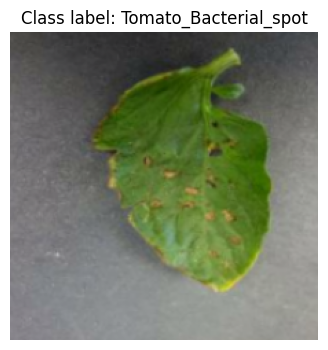

In [19]:
# viewing images 
plt.figure(figsize = (4,4))

for images,labels in train_dataset.take(1):
    image = images[0].numpy().astype("uint8")
    label = labels[0].numpy()
    classname = class_names[label]

    plt.imshow(image)
    plt.title(f"Class label: {classname}")
    plt.axis("off")
    break #prevents loop to overwork

plt.show()

#### Now we need to look at the imbalance of our dataset, given we know from general eye that which class is rare and which is common, but the model doesn't that's why we need to look at the distribution of our dataset.
---
This will further help us to give class weights to the rare classes and we don't even need to oversample or anything. 

In [20]:
import os
import numpy as np

In [22]:
class_counts = {}
for class_name in class_names:
    folder_path = os.path.join(dataset_dir, class_name) # building path to each folder
    num_images = len(os.listdir(folder_path)) # count the number of images in that folder
    class_counts[class_name] = num_images #add the number of images as value to the key which is class name in the class counts dictionary

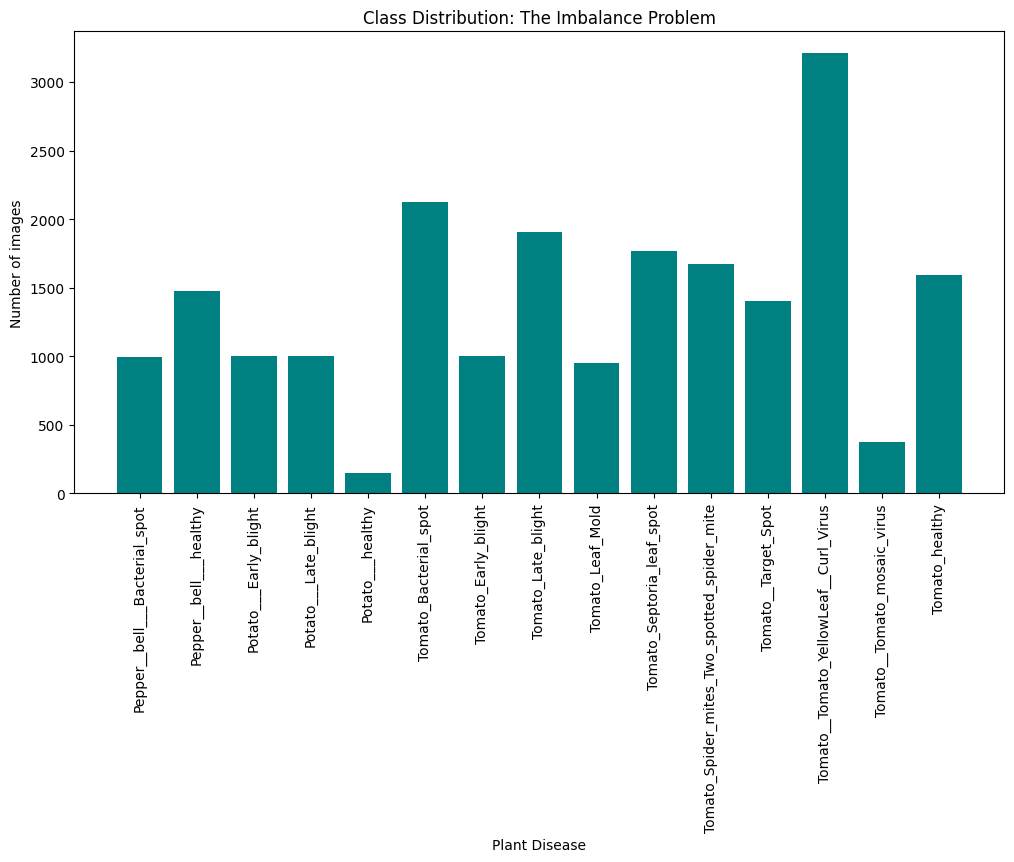

In [25]:
## plotting the imbalance
plt.figure(figsize = (12,6))
plt.bar(class_counts.keys(), class_counts.values(), color = 'teal')
plt.xticks(rotation=90) #rotating long class names 
plt.title('Class Distribution: The Imbalance Problem')
plt.xlabel('Plant Disease')
plt.ylabel('Number of images')
plt.show()

### Clearly we can see pepper and potato are very less compared to tomato. This is why we will use class weights which will balance out giving more importance to less common images/classes. 
#### The standard formula used in industry to calculate class weights is:
---
Wj =  (Number of Classes × Samples in Classj) / Total Samples
1. If a class has a lot of samples, the denominator is huge, so the weight (penalty) drops close to 1.0.
2. If a class has very few samples, the denominator is tiny, so the weight (penalty) shoots up.

In math, if you want a number to get bigger when your count gets smaller (an inverse relationship), you must put the count in the denominator (the bottom) of the fraction.

Because we want Rare (small count) = High Penalty (big weight), the count must be at the bottom hence the formula will be flipped.

In [27]:
from sklearn.utils.class_weight import compute_class_weight

#We need a list of all the counts we just found
counts = list(class_counts.values())
total_samples = sum(counts)
num_classes = len(class_names)

#Calculate the weights manually using the industry formula
weights = []
for count in counts:
    weight = total_samples / (num_classes * count)
    weights.append(weight)

#Create the dictionary that Keras requires (e.g., {0: 1.2, 1: 5.4, 2: 0.8})
class_weight_dict = {i: weight for i, weight in enumerate(weights)}

for i,name in enumerate(class_names):
    print(f"{name}: Penalty Weight = {class_weight_dict[i]:.2f}")

Pepper__bell___Bacterial_spot: Penalty Weight = 1.38
Pepper__bell___healthy: Penalty Weight = 0.93
Potato___Early_blight: Penalty Weight = 1.38
Potato___Late_blight: Penalty Weight = 1.38
Potato___healthy: Penalty Weight = 9.05
Tomato_Bacterial_spot: Penalty Weight = 0.65
Tomato_Early_blight: Penalty Weight = 1.38
Tomato_Late_blight: Penalty Weight = 0.72
Tomato_Leaf_Mold: Penalty Weight = 1.45
Tomato_Septoria_leaf_spot: Penalty Weight = 0.78
Tomato_Spider_mites_Two_spotted_spider_mite: Penalty Weight = 0.82
Tomato__Target_Spot: Penalty Weight = 0.98
Tomato__Tomato_YellowLeaf__Curl_Virus: Penalty Weight = 0.43
Tomato__Tomato_mosaic_virus: Penalty Weight = 3.69
Tomato_healthy: Penalty Weight = 0.86


Look at Potato___healthy, It has a massive penalty weight of 9.05, meaning there are hardly any pictures of healthy potatoes in this dataset. On the other end, Tomato__Tomato_YellowLeaf__Curl_Virus is only 0.43, meaning the dataset is absolutely flooded with it.

If we hadn't calculated these weights, the model would have just blindly guessed "Yellow Leaf Curl Virus" half the time and completely ignored healthy potatoes.